# Reto 1: Modelo de selección de equipos de fútbol español


### Importar librerías

In [211]:
##Importación de librerias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
import matplotlib.pyplot as plt
!pip install openpyxl




   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   ---------------------------------------  245.8/250.9 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 3.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importar información para análisis
Suponiendo que utilizamos un API desde Google en este caso se añade la ruta donde se almacenan los datos.

In [164]:
# Ruta base donde están las subcarpetas
base_path = r"C:\Users\NOEJGARZON\Documents\GCO\Data"

# Lista para almacenar los DataFrames
dataframes = []
csv_encontrados = []

# Buscar todos los archivos CSV dentro de las subcarpetas
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(".csv"):
            file_path = os.path.join(root, file)
            csv_encontrados.append(file_path)

# Mostrar los archivos encontrados
if not csv_encontrados:
    print("❌ No se encontró ningún archivo .csv en las subcarpetas.")
else:
    print(f"📄 Se encontraron {len(csv_encontrados)} archivos CSV:")
    for f in csv_encontrados:
        print("   -", f)

    # Leer y unir los archivos CSV en un solo DataFrame
    for file_path in csv_encontrados:
        try:
            df = pd.read_csv(file_path)
            temporada = os.path.basename(os.path.dirname(file_path))  # nombre de la carpeta como temporada
            df["Temporada"] = temporada
            dataframes.append(df)
        except Exception as e:
            print(f"⚠️ Error leyendo {file_path}: {e}")

    # Concatenar todos los DataFrames
    if dataframes:
        df_final = pd.concat(dataframes, ignore_index=True)
        print("✅ Archivos combinados correctamente.")
        print("🧩 Dimensiones del DataFrame final:", df_final.shape)
    else:
        print("⚠️ No se pudo leer ningún archivo CSV válido.")


📄 Se encontraron 10 archivos CSV:
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2008-09\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2009-10\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2010-11\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2011-12\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2012-13\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2013-14\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2014-15\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2015-16\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2016-17\1-liga.csv
   - C:\Users\NOEJGARZON\Documents\GCO\Data\2017-18\1-liga.csv
✅ Archivos combinados correctamente.
🧩 Dimensiones del DataFrame final: (3800, 7)


### Exploración de datos

In [165]:
from IPython.display import display  # Importa display para visualización limpia
## Revisión rápida del DataFrame final

# Dimensiones del DataFrame
print("Dimensiones del DataFrame:", df_final.shape)

# Tipos de datos
print("\nTipos de datos:")
display(df_final.dtypes.to_frame("Tipo de Dato"))

# Primeras filas del DataFrame
print("\nPrimeras filas del DataFrame:")
display(df_final.head(10))  # Puedes cambiar el número de filas a mostrar

Dimensiones del DataFrame: (3800, 7)

Tipos de datos:


,Tipo de Dato
Round,object
Date,object
Team 1,object
FT,object
HT,object
Team 2,object
Temporada,object



Primeras filas del DataFrame:


,Round,Date,Team 1,FT,HT,Team 2,Temporada
0,?,(Sat) 30 Aug 2008 (34),RCD Español (1),1-0,0-0,Real Valladolid CF (1),2008-09
1,?,(Sat) 30 Aug 2008 (34),Valencia CF (1),3-0,2-0,RCD Mallorca (1),2008-09
2,?,(Sun) 31 Aug 2008 (34),Athletic Club Bilbao (1),1-3,0-2,UD Almería (1),2008-09
3,?,(Sun) 31 Aug 2008 (34),Atlético Madrid (1),4-0,3-0,Málaga CF (1),2008-09
4,?,(Sun) 31 Aug 2008 (34),Real Betis (1),0-1,0-1,Recreativo Huelva (1),2008-09
5,?,(Sun) 31 Aug 2008 (34),RCD La Coruña (1),2-1,1-0,Real Madrid CF (1),2008-09
6,?,(Sun) 31 Aug 2008 (34),CD Numancia (1),1-0,1-0,FC Barcelona (1),2008-09
7,?,(Sun) 31 Aug 2008 (34),CA Osasuna (1),1-1,0-0,Villarreal CF (1),2008-09
8,?,(Sun) 31 Aug 2008 (34),Real Racing Santander (1),1-1,0-0,Sevilla FC (1),2008-09
9,?,(Sun) 31 Aug 2008 (34),Sporting Gijón (1),1-2,1-1,Getafe CF (1),2008-09


	Descriptions:
		Round - Discard
		Date -  (Day of week of match) Date (week of year) Eg. (Fri) 19 Aug 2016 (33) 
		Team 1 - Team (Round) Eg. RCD La Coruña (1) .. This is the Home team
		FT - Score at Final Time E.g. 2-1
		HT - Score at Half Time  E.g. 0-0
		Team 2 - Team (Round) E.g. SD Eibar (1) .. This is the Away team

In [166]:
## Revisión de valores faltantes
print("\nValores faltantes por columna:")
missing_values = df_final.isnull().sum()
print(missing_values[missing_values > 0])

# 3Revisión de duplicados
duplicates = df_final.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {duplicates}")

# Revisión de valores únicos por columna
print("\nValores únicos por columna:")
for col in df_final.columns:
    print(f"{col}: {df_final[col].nunique()} únicos")


Valores faltantes por columna:
Series([], dtype: int64)

Número de filas duplicadas: 0

Valores únicos por columna:
Round: 1 únicos
Date: 1155 únicos
Team 1: 1179 únicos
FT: 54 únicos
HT: 28 únicos
Team 2: 1180 únicos
Temporada: 10 únicos


In [167]:
df_final.sample(3)

,Round,Date,Team 1,FT,HT,Team 2,Temporada
3583,?,(Thu) 21 Dec 2017 (51),SD Eibar (17),4-1,2-1,Girona FC (17),2017-18
1565,?,(Sun) 23 Sep 2012 (38),Levante UD (5),2-1,0-1,Real Sociedad (5),2012-13
2400,?,(Fri) 28 Nov 2014 (47),Real Sociedad (13),3-0,2-0,Elche CF (13),2014-15


### Data Profiling

In [169]:
## Limpieza y transformación de datos en el datatime

# Función para extraer información de la fecha
def parse_date(date_str):
    # Extraer la semana (número al final entre paréntesis)
    semana = re.search(r'\((\d+)\)$', date_str)
    semana = int(semana.group(1)) if semana else None
    
    # Extraer la fecha (remover día de la semana y semana)
    fecha_limpia = re.sub(r'^\([A-Za-z]+\)\s+', '', date_str)
    fecha_limpia = re.sub(r'\s+\(\d+\)$', '', fecha_limpia)
    
    # Parsear la fecha
    fecha_obj = datetime.strptime(fecha_limpia, '%d %b %Y')
    
    return {
        'Dia': fecha_obj.day,
        'Mes': fecha_obj.month,
        'Año': fecha_obj.year,
        'Fecha': fecha_obj.strftime('%d/%m/%Y'),
        'Semana': semana
    }

# Función para extraer el número de ronda del equipo
def extraer_ronda(team_str):
    ronda = re.search(r'\((\d+)\)$', team_str)
    return int(ronda.group(1)) if ronda else None

# Aplicar las funciones al df_final
fecha_info = df_final['Date'].apply(parse_date).apply(pd.Series)
df_final['Dia'] = fecha_info['Dia']
df_final['Mes'] = fecha_info['Mes']
df_final['Año'] = fecha_info['Año']
df_final['Fecha'] = fecha_info['Fecha']
df_final['Semana'] = fecha_info['Semana']

# Extraer rondas de los equipos
df_final['Ronda Team 1'] = df_final['Team 1'].apply(extraer_ronda)
df_final['Ronda Team 2'] = df_final['Team 2'].apply(extraer_ronda)

# Reorganizar columnas (opcional)
columnas_ordenadas = ['Round', 'Date', 'Dia', 'Mes', 'Año', 'Fecha', 'Semana', 
                      'Team 1', 'Ronda Team 1', 'FT', 'HT', 
                      'Team 2', 'Ronda Team 2', 'Temporada']
df_final = df_final[columnas_ordenadas]

display(df_final.sample(10))  

,Round,Date,Dia,Mes,Año,Fecha,Semana,Team 1,Ronda Team 1,FT,HT,Team 2,Ronda Team 2,Temporada
2575,?,(Wed) 8 Apr 2015 (14),8,4,2015,08/04/2015,14,RCD La Coruña (30),30,1-1,0-0,Córdoba CF (30),30,2014-15
409,?,(Sun) 20 Sep 2009 (37),20,9,2009,20/09/2009,37,Real Zaragoza (3),3,1-2,1-1,Real Valladolid CF (3),3,2009-10
3626,?,(Sun) 28 Jan 2018 (4),28,1,2018,28/01/2018,4,CD Leganés (20),20,3-2,1-0,RCD Español (21),21,2017-18
130,?,(Sat) 6 Dec 2008 (48),6,12,2008,06/12/2008,48,FC Barcelona (14),14,4-0,2-0,Valencia CF (14),14,2008-09
2993,?,(Wed) 20 Apr 2016 (16),20,4,2016,20/04/2016,16,RCD La Coruña (34),34,0-8,0-2,FC Barcelona (34),34,2015-16
2555,?,(Sat) 21 Mar 2015 (11),21,3,2015,21/03/2015,11,Rayo Vallecano (28),28,1-0,1-0,Málaga CF (28),28,2014-15
2628,?,(Sun) 3 May 2015 (17),3,5,2015,03/05/2015,17,Valencia CF (35),35,3-1,1-0,SD Eibar (35),35,2014-15
3415,?,(Sun) 21 May 2017 (20),21,5,2017,21/05/2017,20,Atlético Madrid (38),38,3-1,2-0,Athletic Club Bilbao (38),38,2016-17
17,?,(Sun) 14 Sep 2008 (36),14,9,2008,14/09/2008,36,Recreativo Huelva (2),2,0-1,0-0,RCD Español (2),2,2008-09
41,?,(Sat) 27 Sep 2008 (38),27,9,2008,27/09/2008,38,RCD Español (5),5,1-2,1-0,FC Barcelona (5),5,2008-09


In [170]:
## Limpieza y transformación de datos en FT y HT
df_final_data_q = df_final.copy()

# Separar la columna FT
df_final_data_q[['Team 1 FT', 'Team 2 FT']] = df_final_data_q['FT'].str.split('-', expand=True)

# Separar la columna HT
df_final_data_q[['Team 1 HT', 'Team 2 HT']] = df_final_data_q['HT'].str.split('-', expand=True)

# Convertir a tipo numérico (int)
df_final_data_q['Team 1 FT'] = pd.to_numeric(df_final_data_q['Team 1 FT'])
df_final_data_q['Team 2 FT'] = pd.to_numeric(df_final_data_q['Team 2 FT'])
df_final_data_q['Team 1 HT'] = pd.to_numeric(df_final_data_q['Team 1 HT'])
df_final_data_q['Team 2 HT'] = pd.to_numeric(df_final_data_q['Team 2 HT'])

# Reorganizar columnas (opcional) - colocando las nuevas columnas después de FT y HT
columnas_ordenadas = ['Round', 'Date', 'Dia', 'Mes', 'Año', 'Fecha', 'Semana', 
                      'Team 1', 'Ronda Team 1', 
                      'FT', 'Team 1 FT', 'Team 2 FT',
                      'HT', 'Team 1 HT', 'Team 2 HT',
                      'Team 2', 'Ronda Team 2', 'Temporada']

df_final_data_q = df_final_data_q[columnas_ordenadas]


display(df_final_data_q.sample(3))  

,Round,Date,Dia,Mes,Año,Fecha,Semana,Team 1,Ronda Team 1,FT,Team 1 FT,Team 2 FT,HT,Team 1 HT,Team 2 HT,Team 2,Ronda Team 2,Temporada
3639,?,(Fri) 9 Feb 2018 (6),9,2,2018,09/02/2018,6,Athletic Club Bilbao (23),23,0-0,0,0,0-0,0,0,UD Las Palmas (23),23,2017-18
1727,?,(Sun) 27 Jan 2013 (3),27,1,2013,27/01/2013,3,Real Madrid CF (21),21,4-0,4,0,0-0,0,0,Getafe CF (21),21,2012-13
865,?,(Sun) 14 Nov 2010 (45),14,11,2010,14/11/2010,45,RCD Mallorca (11),11,0-0,0,0,0-0,0,0,RCD La Coruña (11),11,2010-11


In [171]:
# Función para extraer el nombre del equipo sin el paréntesis
def extraer_nombre_equipo(team_str):
    # Remover el contenido entre paréntesis y espacios extra
    nombre = re.sub(r'\s*\(\d+\)\s*$', '', team_str).strip()
    return nombre

# Aplicar la función a las columnas Team 1 y Team 2
df_final_data_q['Team 1'] = df_final_data_q['Team 1'].apply(extraer_nombre_equipo)
df_final_data_q['Team 2'] = df_final_data_q['Team 2'].apply(extraer_nombre_equipo)

display(df_final_data_q.sample(3))  

,Round,Date,Dia,Mes,Año,Fecha,Semana,Team 1,Ronda Team 1,FT,Team 1 FT,Team 2 FT,HT,Team 1 HT,Team 2 HT,Team 2,Ronda Team 2,Temporada
1453,?,(Wed) 11 Apr 2012 (15),11,4,2012,11/04/2012,15,Atlético Madrid,32,1-4,1,4,0-1,0,1,Real Madrid CF,32,2011-12
1704,?,(Sat) 12 Jan 2013 (1),12,1,2013,12/01/2013,1,Real Valladolid CF,19,3-1,3,1,1-1,1,1,RCD Mallorca,19,2012-13
1829,?,(Mon) 15 Apr 2013 (15),15,4,2013,15/04/2013,15,RCD Mallorca,31,1-0,1,0,0-0,0,0,RC Celta Vigo,31,2012-13


In [172]:
# Dataframe final con las columnas seleccionadas
df = df_final_data_q[['Fecha', 'Dia', 'Mes', 'Año', 'Semana', 
                       'Team 1', 'Ronda Team 1', 
                       'Team 2', 'Ronda Team 2', 
                       'Team 1 FT', 'Team 2 FT', 
                       'Team 1 HT', 'Team 2 HT']].copy()

df = df.rename(columns={
    'Team 1': 'Equipo Local',
    'Team 2': 'Equipo Visitante',
    'Ronda Team 1': 'Ronda Local',
    'Ronda Team 2': 'Ronda Visitante',
    'Team 1 FT': 'Goles Local FT',
    'Team 2 FT': 'Goles Visitante FT',
    'Team 1 HT': 'Goles Local HT',
    'Team 2 HT': 'Goles Visitante HT'
})


display(df.head(3))  

,Fecha,Dia,Mes,Año,Semana,Equipo Local,Ronda Local,Equipo Visitante,Ronda Visitante,Goles Local FT,Goles Visitante FT,Goles Local HT,Goles Visitante HT
0,30/08/2008,30,8,2008,34,RCD Español,1,Real Valladolid CF,1,1,0,0,0
1,30/08/2008,30,8,2008,34,Valencia CF,1,RCD Mallorca,1,3,0,2,0
2,31/08/2008,31,8,2008,34,Athletic Club Bilbao,1,UD Almería,1,1,3,0,2


### EDA

In [173]:
# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [174]:
# 1. RESUMEN ESTADÍSTICO BÁSICO
# ============================================
print("="*80)
print("ANÁLISIS EXPLORATORIO DE DATOS - PARTIDOS DE FÚTBOL")
print("="*80)
print("\nINFORMACIÓN GENERAL DEL DATASET")
print("-"*80)
print(f"Número total de partidos: {len(df)}")
print(f"Rango de fechas: {df['Fecha'].min()} hasta {df['Fecha'].max()}")
print(f"Años analizados: {df['Año'].min()} - {df['Año'].max()}")
print(f"\nColumnas del dataset: {list(df.columns)}")
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

# Información detallada
print("\n ESTADÍSTICAS DESCRIPTIVAS")
print("-"*80)
print(df.describe())

# Verificar valores nulos
print("\n VALORES NULOS POR COLUMNA")
print("-"*80)
print(df.isnull().sum())

ANÁLISIS EXPLORATORIO DE DATOS - PARTIDOS DE FÚTBOL

INFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------------------------------------
Número total de partidos: 3800
Rango de fechas: 01/02/2009 hasta 31/12/2015
Años analizados: 2008 - 2018

Columnas del dataset: ['Fecha', 'Dia', 'Mes', 'Año', 'Semana', 'Equipo Local', 'Ronda Local', 'Equipo Visitante', 'Ronda Visitante', 'Goles Local FT', 'Goles Visitante FT', 'Goles Local HT', 'Goles Visitante HT']

Dimensiones: 3800 filas x 13 columnas

 ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------
               Dia          Mes          Año       Semana  Ronda Local  \
count  3800.000000  3800.000000  3800.000000  3800.000000  3800.000000   
mean     15.947368     6.063421  2013.072105    23.925526    19.499211   
std       8.796154     3.794113     2.906558    16.611282    10.967203   
min       1.000000     1.000000  2008.000000     0.000000     1.000000 

In [175]:
# ============================================
# 2. ANÁLISIS DE RESULTADOS
# ============================================
print("\n" + "="*80)
print(" ANÁLISIS DE RESULTADOS")
print("="*80)

# Calcular resultados
df['Resultado'] = df.apply(lambda x: 'Victoria Local' if x['Goles Local FT'] > x['Goles Visitante FT'] 
                            else ('Victoria Visitante' if x['Goles Local FT'] < x['Goles Visitante FT'] 
                                  else 'Empate'), axis=1)

resultados_count = df['Resultado'].value_counts()
print("\nDistribución de Resultados:")
print(resultados_count)
print(f"\nPorcentajes:")
print(resultados_count / len(df) * 100)


 ANÁLISIS DE RESULTADOS

Distribución de Resultados:
Resultado
Victoria Local        1845
Victoria Visitante    1076
Empate                 879
Name: count, dtype: int64

Porcentajes:
Resultado
Victoria Local        48.552632
Victoria Visitante    28.315789
Empate                23.131579
Name: count, dtype: float64


In [176]:
# Insights de resultados
victoria_local = resultados_count.get('Victoria Local', 0)
victoria_visitante = resultados_count.get('Victoria Visitante', 0)
empates = resultados_count.get('Empate', 0)

print("\n INSIGHTS - RESULTADOS:")
print("-"*80)
print(f"✓ Ventaja Local: Los equipos locales ganaron {victoria_local} de {len(df)} partidos ({victoria_local/len(df)*100:.1f}%)")
print(f"✓ Visitantes: Los equipos visitantes ganaron {victoria_visitante} partidos ({victoria_visitante/len(df)*100:.1f}%)")
print(f"✓ Empates: Se registraron {empates} empate(s) ({empates/len(df)*100:.1f}%)")



 INSIGHTS - RESULTADOS:
--------------------------------------------------------------------------------
✓ Ventaja Local: Los equipos locales ganaron 1845 de 3800 partidos (48.6%)
✓ Visitantes: Los equipos visitantes ganaron 1076 partidos (28.3%)
✓ Empates: Se registraron 879 empate(s) (23.1%)


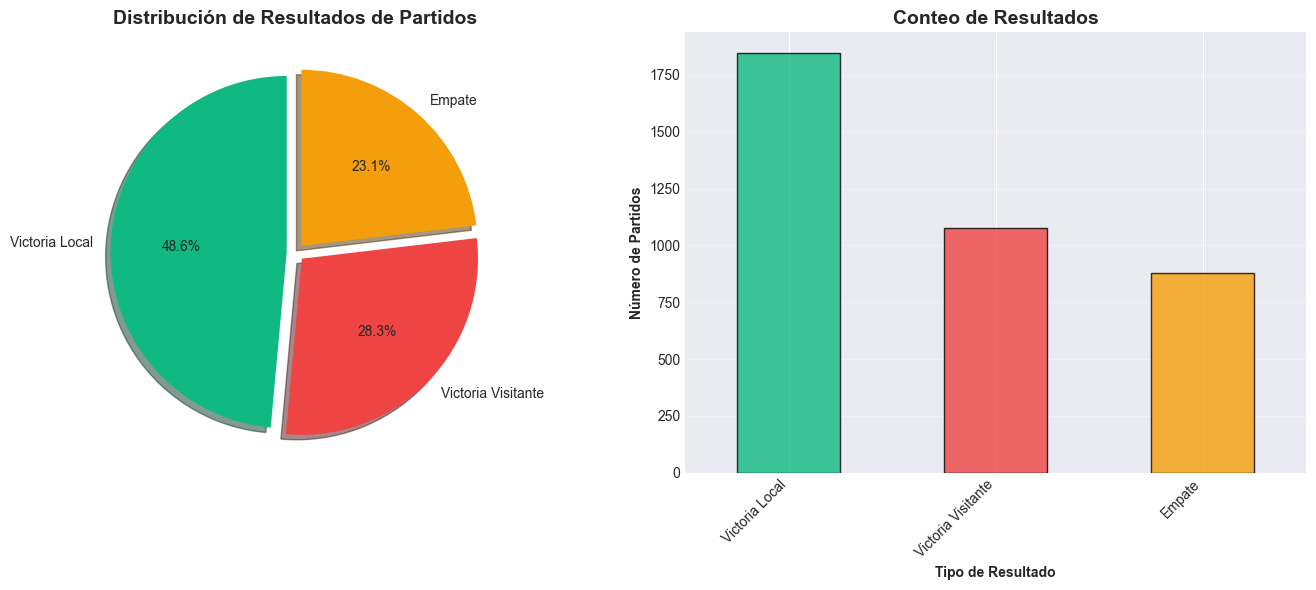

In [177]:
# Gráfico de Resultados (Torta)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#10b981', '#ef4444', '#f59e0b']
explode = (0.05, 0.05, 0.05)
ax1.pie(resultados_count.values, labels=resultados_count.index, autopct='%1.1f%%',
        colors=colors, explode=explode, shadow=True, startangle=90)
ax1.set_title('Distribución de Resultados de Partidos', fontsize=14, fontweight='bold')

# Gráfico de barras de resultados
resultados_count.plot(kind='bar', ax=ax2, color=colors, edgecolor='black', alpha=0.8)
ax2.set_title('Conteo de Resultados', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tipo de Resultado', fontweight='bold')
ax2.set_ylabel('Número de Partidos', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_distribucion_resultados.png', dpi=300, bbox_inches='tight')
plt.show()

In [180]:
# ============================================
# 3. ANÁLISIS DE GOLES
# ============================================
print("\n" + "="*80)
print("⚽ ANÁLISIS DE GOLES")
print("="*80)

# Estadísticas de goles
total_goles = df['Goles Local FT'].sum() + df['Goles Visitante FT'].sum()
avg_goles_local = df['Goles Local FT'].mean()
avg_goles_visitante = df['Goles Visitante FT'].mean()
avg_goles_partido = (df['Goles Local FT'] + df['Goles Visitante FT']).mean()

print(f"\nTotal de goles en todos los partidos: {total_goles}")
print(f"Promedio de goles por partido: {avg_goles_partido:.2f}")
print(f"Promedio de goles Local: {avg_goles_local:.2f}")
print(f"Promedio de goles Visitante: {avg_goles_visitante:.2f}")
print(f"Diferencia promedio: {abs(avg_goles_local - avg_goles_visitante):.2f} goles")

print("\n💡 INSIGHTS - GOLES:")
print("-"*80)
print(f"✓ Efectividad Ofensiva: Los locales promedian {avg_goles_local:.2f} vs {avg_goles_visitante:.2f} de visitantes")
print(f"✓ Productividad: Se anotan en promedio {avg_goles_partido:.2f} goles por partido")

if avg_goles_local > avg_goles_visitante:
    print(f"✓ Los equipos locales son {((avg_goles_local/avg_goles_visitante - 1)*100):.1f}% más efectivos anotando")
else:
    print(f"✓ Los equipos visitantes son {((avg_goles_visitante/avg_goles_local - 1)*100):.1f}% más efectivos anotando")


⚽ ANÁLISIS DE GOLES

Total de goles en todos los partidos: 10554
Promedio de goles por partido: 2.78
Promedio de goles Local: 1.63
Promedio de goles Visitante: 1.15
Diferencia promedio: 0.47 goles

💡 INSIGHTS - GOLES:
--------------------------------------------------------------------------------
✓ Efectividad Ofensiva: Los locales promedian 1.63 vs 1.15 de visitantes
✓ Productividad: Se anotan en promedio 2.78 goles por partido
✓ Los equipos locales son 41.2% más efectivos anotando



✓ Primer Tiempo - Local: 0.73 goles | Visitante: 0.50 goles
✓ Segundo Tiempo - Local: 0.89 goles | Visitante: 0.65 goles


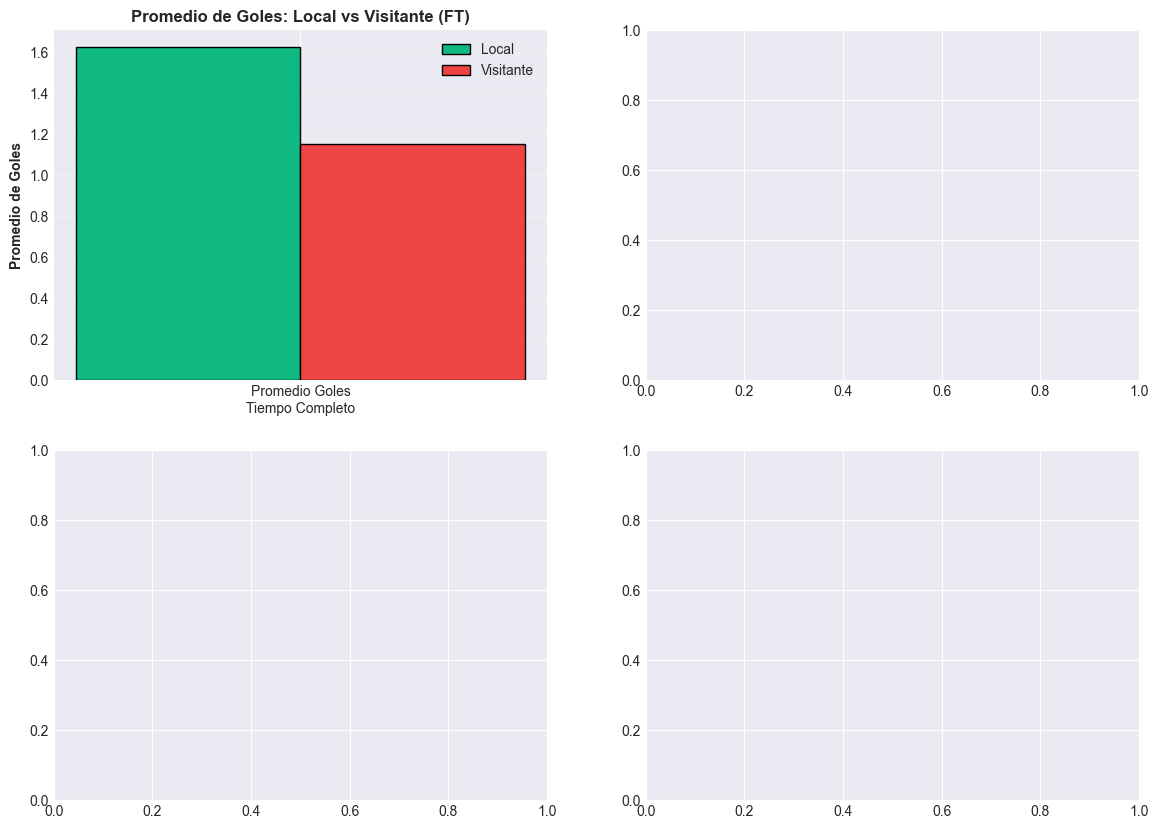

In [181]:
# Análisis de medio tiempo
avg_goles_local_ht = df['Goles Local HT'].mean()
avg_goles_visitante_ht = df['Goles Visitante HT'].mean()
print(f"\n✓ Primer Tiempo - Local: {avg_goles_local_ht:.2f} goles | Visitante: {avg_goles_visitante_ht:.2f} goles")
print(f"✓ Segundo Tiempo - Local: {(avg_goles_local - avg_goles_local_ht):.2f} goles | Visitante: {(avg_goles_visitante - avg_goles_visitante_ht):.2f} goles")

# Gráficos de goles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Comparación Local vs Visitante (FT)
categorias = ['Promedio Goles\nTiempo Completo']
x = np.arange(len(categorias))
width = 0.35

axes[0, 0].bar(x - width/2, [avg_goles_local], width, label='Local', color='#10b981', edgecolor='black')
axes[0, 0].bar(x + width/2, [avg_goles_visitante], width, label='Visitante', color='#ef4444', edgecolor='black')
axes[0, 0].set_ylabel('Promedio de Goles', fontweight='bold')
axes[0, 0].set_title('Promedio de Goles: Local vs Visitante (FT)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categorias)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

C:\Users\NOEJGARZON\AppData\Local\Temp\ipykernel_57920\3282330429.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot([goles_data['Local FT'], goles_data['Visitante FT'],


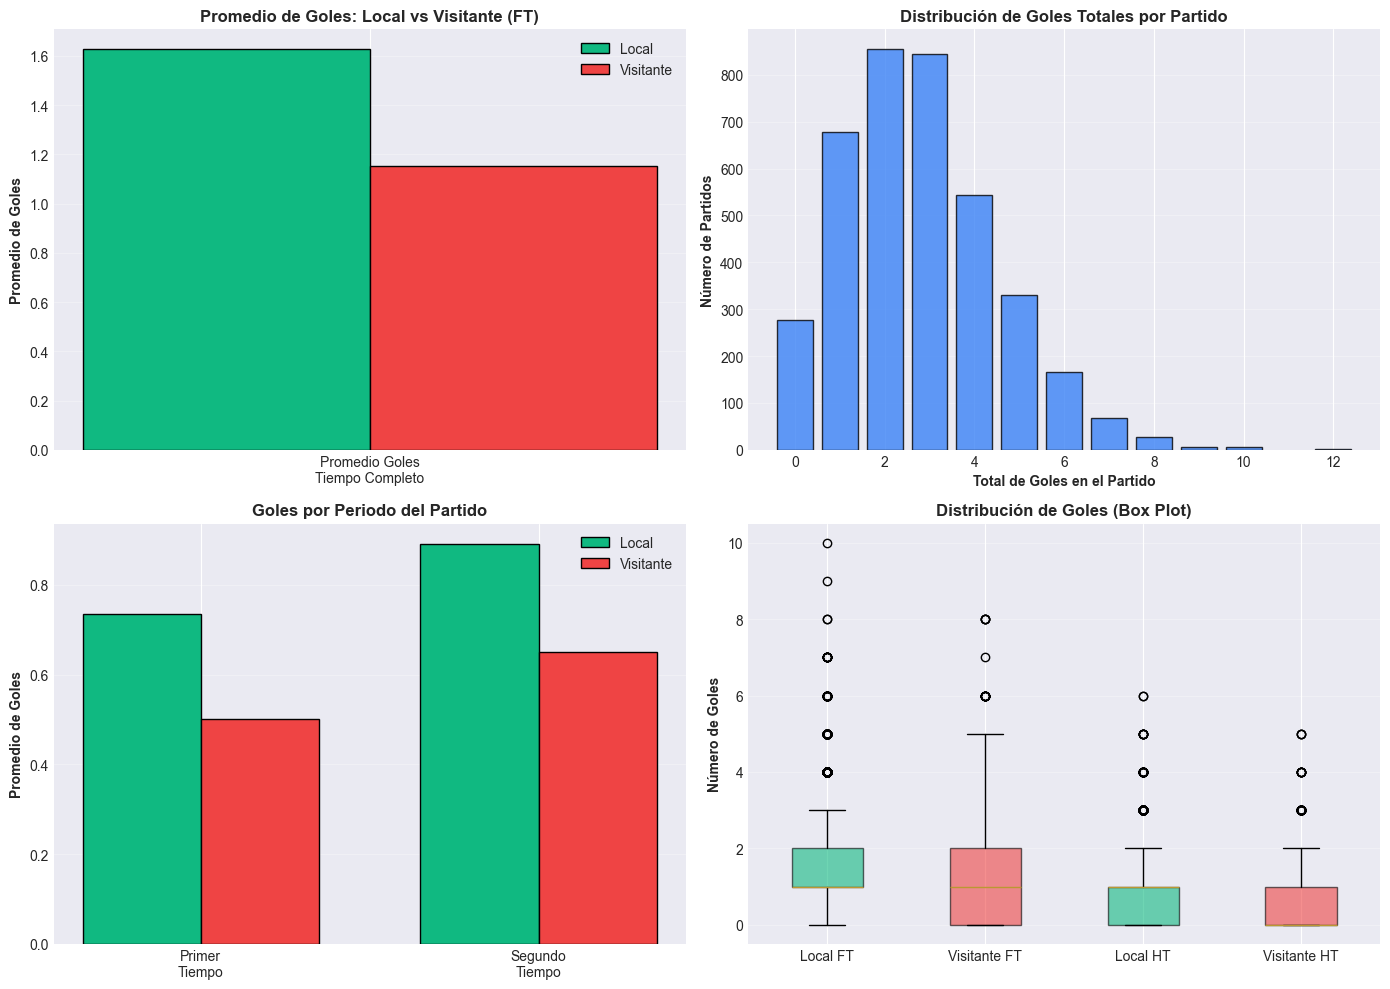

In [182]:
# Gráficos de goles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Comparación Local vs Visitante (FT)
categorias = ['Promedio Goles\nTiempo Completo']
x = np.arange(len(categorias))
width = 0.35

axes[0, 0].bar(x - width/2, [avg_goles_local], width, label='Local', color='#10b981', edgecolor='black')
axes[0, 0].bar(x + width/2, [avg_goles_visitante], width, label='Visitante', color='#ef4444', edgecolor='black')
axes[0, 0].set_ylabel('Promedio de Goles', fontweight='bold')
axes[0, 0].set_title('Promedio de Goles: Local vs Visitante (FT)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categorias)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución de goles por partido
df['Total Goles'] = df['Goles Local FT'] + df['Goles Visitante FT']
goles_dist = df['Total Goles'].value_counts().sort_index()
axes[0, 1].bar(goles_dist.index, goles_dist.values, color='#3b82f6', edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Total de Goles en el Partido', fontweight='bold')
axes[0, 1].set_ylabel('Número de Partidos', fontweight='bold')
axes[0, 1].set_title('Distribución de Goles Totales por Partido', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Comparación Primer Tiempo vs Segundo Tiempo
tiempos = ['Primer\nTiempo', 'Segundo\nTiempo']
local_tiempos = [avg_goles_local_ht, avg_goles_local - avg_goles_local_ht]
visitante_tiempos = [avg_goles_visitante_ht, avg_goles_visitante - avg_goles_visitante_ht]

x2 = np.arange(len(tiempos))
axes[1, 0].bar(x2 - width/2, local_tiempos, width, label='Local', color='#10b981', edgecolor='black')
axes[1, 0].bar(x2 + width/2, visitante_tiempos, width, label='Visitante', color='#ef4444', edgecolor='black')
axes[1, 0].set_ylabel('Promedio de Goles', fontweight='bold')
axes[1, 0].set_title('Goles por Periodo del Partido', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x2)
axes[1, 0].set_xticklabels(tiempos)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 4: Box plot de goles
goles_data = pd.DataFrame({
    'Local FT': df['Goles Local FT'],
    'Visitante FT': df['Goles Visitante FT'],
    'Local HT': df['Goles Local HT'],
    'Visitante HT': df['Goles Visitante HT']
})

bp = axes[1, 1].boxplot([goles_data['Local FT'], goles_data['Visitante FT'], 
                          goles_data['Local HT'], goles_data['Visitante HT']],
                         labels=['Local FT', 'Visitante FT', 'Local HT', 'Visitante HT'],
                         patch_artist=True)

colors_box = ['#10b981', '#ef4444', '#10b981', '#ef4444']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1, 1].set_ylabel('Número de Goles', fontweight='bold')
axes[1, 1].set_title('Distribución de Goles (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_analisis_goles.png', dpi=300, bbox_inches='tight')
plt.show()



📅 ANÁLISIS TEMPORAL

Distribución de partidos por mes:
Mes
1     437
2     413
3     431
4     516
5     367
6      10
8     165
9     410
10    365
11    366
12    320
Name: count, dtype: int64

Distribución de partidos por año:
Año
2008    160
2009    370
2010    390
2011    380
2012    390
2013    380
2014    369
2015    390
2016    370
2017    390
2018    211
Name: count, dtype: int64

Distribución de partidos por semana del año:
Semana
0     60
1    104
2    100
3     99
4    100
5     99
6    100
7    100
8    106
9    134
Name: count, dtype: int64

💡 INSIGHTS - TEMPORALES:
--------------------------------------------------------------------------------
✓ Rango temporal: Los datos abarcan desde 2008 hasta 2018
✓ Años analizados: 11 año(s) diferente(s)
✓ Meses con partidos: 11 mes(es)
✓ Mes con más partidos: Mes 4 con 516 partido(s)
✓ Semanas del año: Entre semana 0 y semana 52


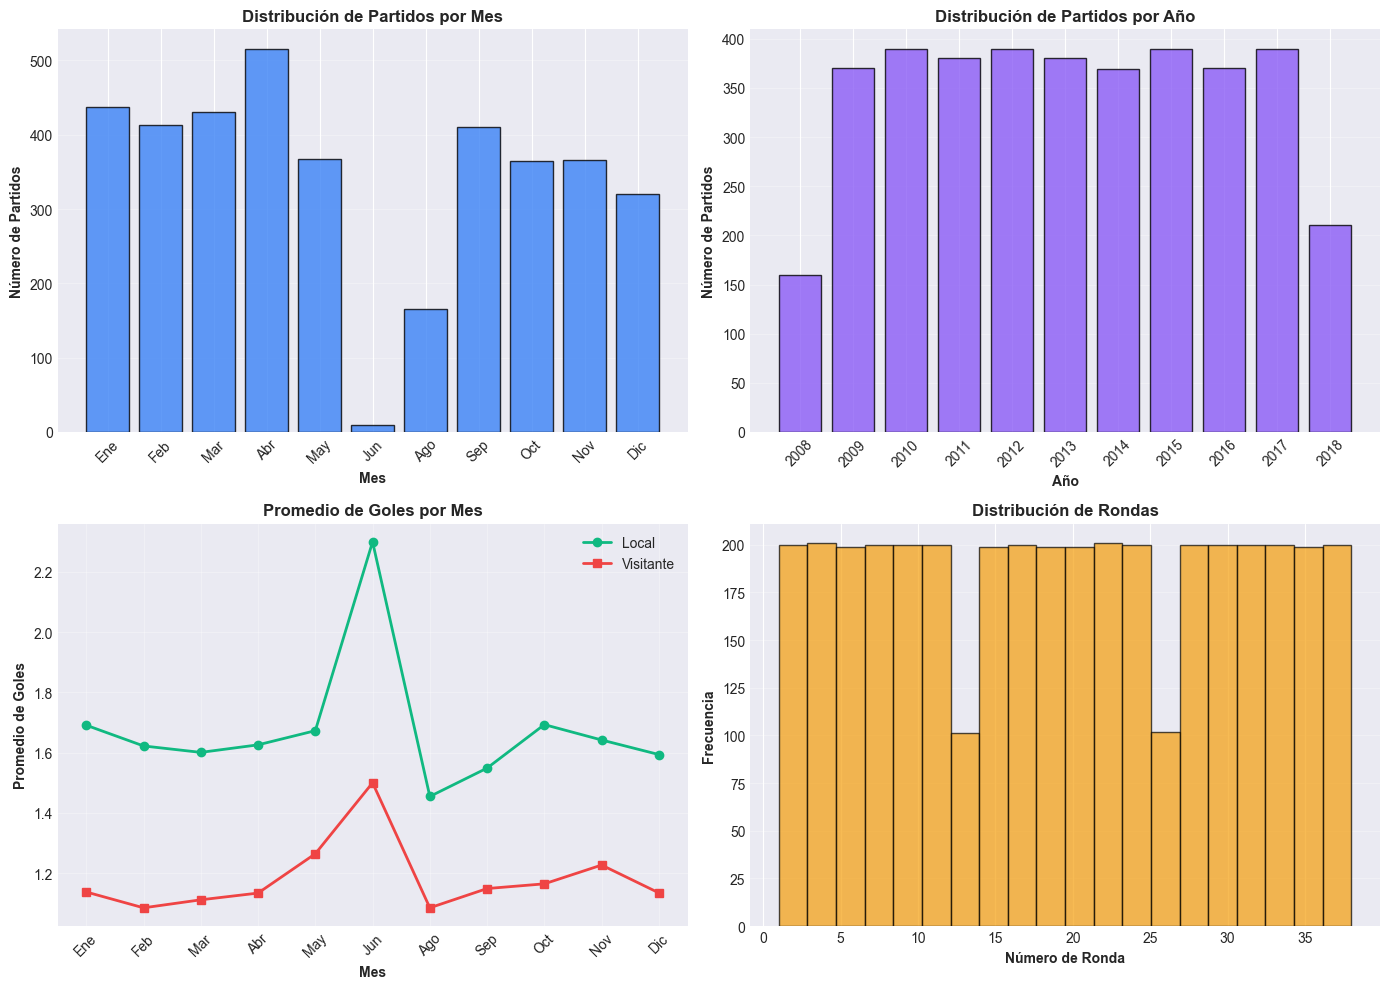

In [183]:
# ============================================
# 4. ANÁLISIS TEMPORAL
# ============================================
print("\n" + "="*80)
print("📅 ANÁLISIS TEMPORAL")
print("="*80)

# Distribución por mes
meses_dist = df['Mes'].value_counts().sort_index()
print("\nDistribución de partidos por mes:")
print(meses_dist)

# Distribución por año
años_dist = df['Año'].value_counts().sort_index()
print("\nDistribución de partidos por año:")
print(años_dist)

# Distribución por día de la semana
print("\nDistribución de partidos por semana del año:")
semanas_dist = df['Semana'].value_counts().sort_index()
print(semanas_dist.head(10))

print("\n💡 INSIGHTS - TEMPORALES:")
print("-"*80)
print(f"✓ Rango temporal: Los datos abarcan desde {df['Año'].min()} hasta {df['Año'].max()}")
print(f"✓ Años analizados: {df['Año'].nunique()} año(s) diferente(s)")
print(f"✓ Meses con partidos: {df['Mes'].nunique()} mes(es)")
print(f"✓ Mes con más partidos: Mes {meses_dist.idxmax()} con {meses_dist.max()} partido(s)")
print(f"✓ Semanas del año: Entre semana {df['Semana'].min()} y semana {df['Semana'].max()}")

# Gráficos temporales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución por mes
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
meses_labels = [meses_nombres[i-1] for i in meses_dist.index]
axes[0, 0].bar(meses_labels, meses_dist.values, color='#3b82f6', edgecolor='black', alpha=0.8)
axes[0, 0].set_xlabel('Mes', fontweight='bold')
axes[0, 0].set_ylabel('Número de Partidos', fontweight='bold')
axes[0, 0].set_title('Distribución de Partidos por Mes', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución por año
axes[0, 1].bar(años_dist.index.astype(str), años_dist.values, color='#8b5cf6', edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Año', fontweight='bold')
axes[0, 1].set_ylabel('Número de Partidos', fontweight='bold')
axes[0, 1].set_title('Distribución de Partidos por Año', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Goles promedio por mes
goles_por_mes = df.groupby('Mes').agg({
    'Goles Local FT': 'mean',
    'Goles Visitante FT': 'mean'
})
x3 = np.arange(len(goles_por_mes))
axes[1, 0].plot(x3, goles_por_mes['Goles Local FT'], marker='o', label='Local', color='#10b981', linewidth=2)
axes[1, 0].plot(x3, goles_por_mes['Goles Visitante FT'], marker='s', label='Visitante', color='#ef4444', linewidth=2)
axes[1, 0].set_xlabel('Mes', fontweight='bold')
axes[1, 0].set_ylabel('Promedio de Goles', fontweight='bold')
axes[1, 0].set_title('Promedio de Goles por Mes', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels([meses_nombres[i-1] for i in goles_por_mes.index], rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Distribución de rondas
rondas_local = df['Ronda Local'].value_counts().sort_index()
axes[1, 1].hist(df['Ronda Local'], bins=20, color='#f59e0b', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Número de Ronda', fontweight='bold')
axes[1, 1].set_ylabel('Frecuencia', fontweight='bold')
axes[1, 1].set_title('Distribución de Rondas', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_analisis_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

In [184]:
# ============================================
# 5. ANÁLISIS DE EQUIPOS
# ============================================
print("\n" + "="*80)
print("🏆 ANÁLISIS DE EQUIPOS")
print("="*80)

# Equipos únicos
equipos_unicos = pd.concat([df['Equipo Local'], df['Equipo Visitante']]).unique()
print(f"\nTotal de equipos únicos: {len(equipos_unicos)}")
print(f"\nEquipos participantes:")
for i, equipo in enumerate(sorted(equipos_unicos), 1):
    print(f"{i}. {equipo}")

# Top equipos como local
print("\n📊 TOP EQUIPOS COMO LOCAL (por frecuencia):")
print(df['Equipo Local'].value_counts().head(10))

# Top equipos como visitante
print("\n📊 TOP EQUIPOS COMO VISITANTE (por frecuencia):")
print(df['Equipo Visitante'].value_counts().head(10))

# ============================================
# 6. TABLA RESUMEN FINAL
# ============================================
print("\n" + "="*80)
print("📋 TABLA RESUMEN DE MÉTRICAS CLAVE")
print("="*80)

resumen = pd.DataFrame({
    'Métrica': [
        'Total Partidos',
        'Victorias Locales',
        'Victorias Visitantes',
        'Empates',
        'Total Goles',
        'Promedio Goles/Partido',
        'Promedio Goles Local',
        'Promedio Goles Visitante',
        'Equipos Únicos',
        'Años Analizados',
        'Meses con Partidos'
    ],
    'Valor': [
        len(df),
        victoria_local,
        victoria_visitante,
        empates,
        total_goles,
        f"{avg_goles_partido:.2f}",
        f"{avg_goles_local:.2f}",
        f"{avg_goles_visitante:.2f}",
        len(equipos_unicos),
        df['Año'].nunique(),
        df['Mes'].nunique()
    ]
})

print(resumen.to_string(index=False))


🏆 ANÁLISIS DE EQUIPOS

Total de equipos únicos: 36

Equipos participantes:
1. Athletic Club Bilbao
2. Atlético Madrid
3. CA Osasuna
4. CD Leganés
5. CD Numancia
6. CD Tenerife
7. Córdoba CF
8. Deportivo Alavés
9. Elche CF
10. FC Barcelona
11. Getafe CF
12. Girona FC
13. Granada CF
14. Hércules CF
15. Levante UD
16. Málaga CF
17. RC Celta Vigo
18. RCD Español
19. RCD La Coruña
20. RCD Mallorca
21. Rayo Vallecano
22. Real Betis
23. Real Madrid CF
24. Real Racing Santander
25. Real Sociedad
26. Real Valladolid CF
27. Real Zaragoza
28. Recreativo Huelva
29. SD Eibar
30. Sevilla FC
31. Sporting Gijón
32. UD Almería
33. UD Las Palmas
34. Valencia CF
35. Villarreal CF
36. Xerez CD

📊 TOP EQUIPOS COMO LOCAL (por frecuencia):
Equipo Local
RCD Español             190
Valencia CF             190
Athletic Club Bilbao    190
Atlético Madrid         190
FC Barcelona            190
Sevilla FC              190
Real Madrid CF          190
Málaga CF               190
Getafe CF               171
Villarr


ANÁLISIS DE CORRELACIONES

Matriz de Correlación:
                         Dia       Mes       Año    Semana  Ronda Local  \
Dia                 1.000000  0.079115 -0.021967  0.154675    -0.166369   
Mes                 0.079115  1.000000 -0.154730  0.996845    -0.623163   
Año                -0.021967 -0.154730  1.000000 -0.148208     0.145799   
Semana              0.154675  0.996845 -0.148208  1.000000    -0.632035   
Ronda Local        -0.166369 -0.623163  0.145799 -0.632035     1.000000   
Ronda Visitante    -0.166677 -0.623016  0.145743 -0.631919     0.999858   
Goles Local FT     -0.018973 -0.010332 -0.011639 -0.011245     0.017232   
Goles Visitante FT  0.024899  0.015927  0.006158  0.017514     0.011059   
Goles Local HT     -0.015818 -0.032678 -0.014069 -0.033408     0.009558   
Goles Visitante HT  0.009015  0.017504 -0.007845  0.017525    -0.012773   

                    Ronda Visitante  Goles Local FT  Goles Visitante FT  \
Dia                       -0.166677       -0.018

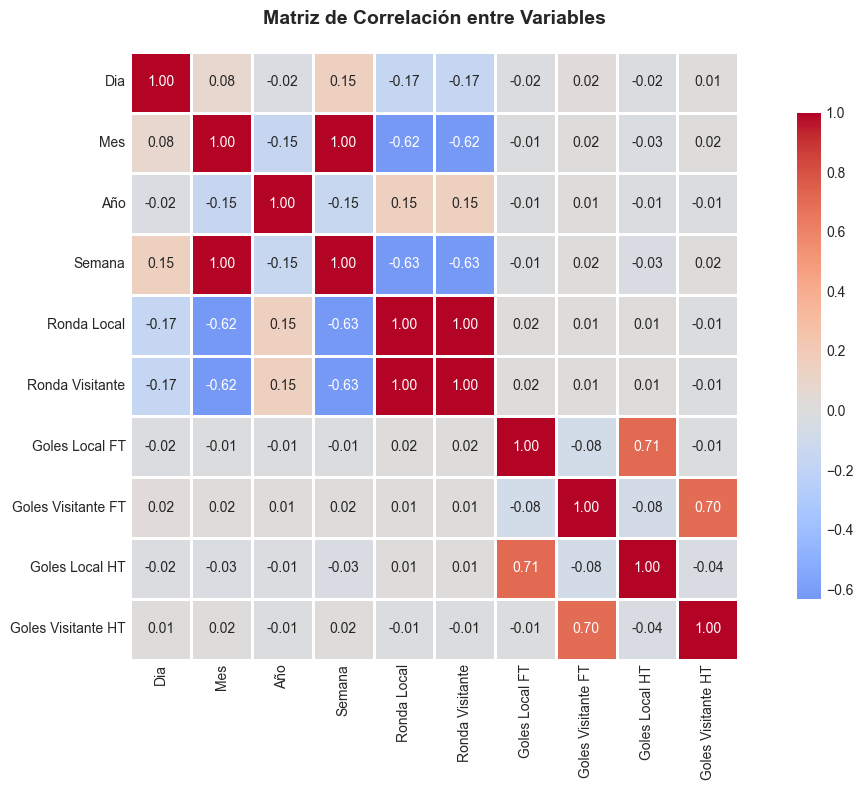

In [185]:
# ============================================
# 7. CORRELACIONES
# ============================================
print("\n" + "="*80)
print("ANÁLISIS DE CORRELACIONES")
print("="*80)

# Matriz de correlación
columnas_numericas = ['Dia', 'Mes', 'Año', 'Semana', 'Ronda Local', 'Ronda Visitante', 
                      'Goles Local FT', 'Goles Visitante FT', 'Goles Local HT', 'Goles Visitante HT']
correlacion = df[columnas_numericas].corr()

print("\nMatriz de Correlación:")
print(correlacion)

# Heatmap de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Fecha               7600 non-null   object
 1   Dia                 7600 non-null   int64 
 2   Mes                 7600 non-null   int64 
 3   Año                 7600 non-null   int64 
 4   Semana              7600 non-null   int64 
 5   Equipo Local        7600 non-null   object
 6   Ronda Local         7600 non-null   int64 
 7   Equipo Visitante    7600 non-null   object
 8   Ronda Visitante     7600 non-null   int64 
 9   Goles Local FT      7600 non-null   int64 
 10  Goles Visitante FT  7600 non-null   int64 
 11  Goles Local HT      7600 non-null   int64 
 12  Goles Visitante HT  7600 non-null   int64 
 13  Resultado           7600 non-null   object
 14  Total Goles         7600 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 890.8+ KB


In [ ]:
## Cargar Investments
# Ruta del archivo 
ruta = r'C:\Users\NOEJGARZON\Documents\GCO\investments.csv'

# Cargar el archivo con codificación compatible
investments = pd.read_csv(ruta, sep=',', encoding='latin1')


In [199]:
# Limpiar y convertir las columnas a numéricas
investments['Investment required'] = (
    investments['Investment required']
    .replace('[\$,]', '', regex=True)  # elimina signos de $ y comas
    .astype(float)
)

investments['Profit per goal'] = (
    investments['Profit per goal']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

investments.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Team                 20 non-null     object 
 1   Investment required  20 non-null     float64
 2   Profit per goal      20 non-null     float64
 3   Unnamed: 3           0 non-null      float64
dtypes: float64(3), object(1)
memory usage: 772.0+ bytes


In [204]:
# Crear columna 'codigo Team' igual al índice numérico
investments['codigo Team'] = investments.index
# Verificar el resultado
investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Team                 20 non-null     object 
 1   Investment required  20 non-null     float64
 2   Profit per goal      20 non-null     float64
 3   Unnamed: 3           0 non-null      float64
 4   codigo Team          20 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes


In [213]:
# Ruta de exportación (carpeta)
ruta_export = r'C:\Users\NOEJGARZON\Documents\GCO\investments_powerbi.xlsx'
# Exportar el DataFrame a Excel
investments.to_excel(ruta_export, index=False)

# Ruta de exportación (carpeta)
ruta_export_2 = r'C:\Users\NOEJGARZON\Documents\GCO\data_powerbi.xlsx'
# Exportar el DataFrame a Excel
df.to_excel(ruta_export_2, index=False)
